QSI1D natural domain layer

---

Kishore Kumar Tarafdar, 30Jun2025

In [ ]:
pwd

'/data1/kishoretarafdar/src.port/multiresolution_kernels.v0/MakingOfVolterraKernelsandExamples1D2D'

        Disable GPU: Force tensorflow to select CPU

In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="-1"    
import tensorflow as tf

2025-07-02 22:25:56.115156: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751475356.135841  217412 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751475356.142247  217412 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-02 22:25:56.164441: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


        Select a GPU with a memory limit

In [1]:
#%% # include ../dirx 
import tensorflow as tf
print(f"TensorFlow version {tf.__version__}")
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
gpus = tf.config.list_physical_devices('GPU')
len(gpus)
mylibpath = [
    '/home/kishoretarafdar/bin',
    '/data1/kishoretarafdar/src2D/GIIR/mra'
    #'/home/k/PLAYGROUND10GB/SKULSTRIPpaper__'
    ]
import sys
[sys.path.insert(1,_) for _ in mylibpath]
del mylibpath

from tf_select_a_gpu import select_a_gpu
# select_gpu = gpus[gpu_id]
memory_limit = 16#32 #GB
select_a_gpu(gpus, gpu_id=1, memory_limit=memory_limit)
# del gpu_id, select_a_gpu, select_gpu

from TFDWT.DWT1DFB import DWT1D, IDWT1D
from TFDWT.DWT2DFB import DWT2D, IDWT2D
import matplotlib.pyplot as plt

2025-07-02 21:51:08.209155: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751473268.230122  202384 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751473268.236456  202384 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-02 21:51:08.258062: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version 2.18.0
Num GPUs Available:  3
3 Physical GPUs available 
Selected 1 Logical GPU with 16 GB memory limit


I0000 00:00:1751473270.317125  202384 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 16384 MB memory:  -> device: 1, name: NVIDIA RTX A6000, pci bus id: 0000:23:00.0, compute capability: 8.6


In [2]:
x = tf.constant([1,2,3,5,5,3,2,1], dtype=tf.float32)
# x = tf.constant([1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0], dtype=tf.float32)
# x = tf.constant([1,0,0,0,0,0,0,0], dtype=tf.float32)
# x = tf.constant([0,0,1,0,0,0,0,0], dtype=tf.float32)
# x = tf.constant([1,0,0,0], dtype=tf.float32)
# x = tf.constant([1,0,0,0], dtype=tf.float32)
# x = tf.constant([1,0], dtype=tf.float32)
# x = tf.constant([0,1,0,0], dtype=tf.float32)
# x = tf.constant([0,0,1,0], dtype=tf.float32)
# x = tf.constant([3.,0,7.,0], dtype=tf.float32)
x = tf.constant([1.,7.,11.,13.], dtype=tf.float32)
# x = tf.constant([3.,7.], dtype=tf.float32)
# x = tf.constant([1,1,1,1], dtype=tf.float32)
# x = tf.constant([21,3,4,5], dtype=tf.float32)
# x = tf.constant([.1,.1,.1,.1], dtype=tf.float32)
# x = tf.constant([1.,2], dtype=tf.float32)

In [ ]:
# h = tf.constant([1,2], dtype=tf.float32)

        new layer

In [1]:
import tensorflow as tf

@tf.keras.utils.register_keras_serializable()
class QSIVolterra1D(tf.keras.layers.Layer):
    def __init__(self, filters=1, kernel_size=4, **kwargs):
        super().__init__(**kwargs)
        self.L = kernel_size
        self.filters = filters

    def build(self, input_shape):
        self.N = input_shape[1]         # sequence length
        self.channels = input_shape[-1] # number of channels
        # Multi-channel kernel: (L, channels)
        kernel_shape = (self.L, self.channels, self.filters)
        self.h = self.add_weight(
            # shape=(self.L, self.channels),
            shape=kernel_shape,
            initializer='glorot_uniform',
            trainable=True,
            name='UIR_kernel'
        )       
        super().build(input_shape)

    def make_h2(self):
        # Quadratic kernel outer product: (L, channels) x (L, channels) -> (L, L, channels)
        h2 = tf.einsum('ico,jco->ijco', self.h, self.h)  # (L, L, channels)
        self.h2 = h2
        # Pad to (N, N, channels)
        paddings = [
            [0, self.N - self.L],
            [0, self.N - self.L],
            [0, 0],
            [0, 0]
        ]
        h2_padded = tf.pad(h2, paddings, mode='CONSTANT', constant_values=0)
        # self.h2_padded = h2_padded
        ## creating h[n-k1,n-k2]
        # N = Npoint
        n = tf.range(self.N)
        # Create circular indices for all possible shifts
        # row_indices = tf.math.mod(n[:, tf.newaxis] - tf.range(N), L)  # [N, N]
        row_indices = tf.math.mod(n[:, tf.newaxis] - n, self.N)
        h2_rows_shifted = tf.gather(h2_padded, row_indices, axis=0)         # [N, N, N]
        h2_columns_shifted = tf.gather(h2_rows_shifted, row_indices,   # [N, N, N]
                                        axis=2, batch_dims=1)
        # self.h2_shifted = h2_columns_shifted
        # print('h2shifted', self.h2_shifted.shape)
        return h2_columns_shifted


    def call(self, x):
        # x: (batch, N, channels)
        x2 = tf.einsum('bic,bjc->bijc', x, x)  # (batch, N, N, channels)
        # print(x2.shape, self.h2_shifted.shape)
        
        h2_shifted = self.make_h2()
        y = tf.einsum('ijkco, bjkc->bio', h2_shifted, x2)
        return y
        
    def get_filter(self):
        return self.h2
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'kernel_size': self.L,
            'filters': self.filters            
        })
        return config

        
if __name__ =='__main__':
    import os
    os.environ["CUDA_VISIBLE_DEVICES"]="-1"    
    ## Example
    # Functional model
    N, channels, filters = 8, 1, 1
    input_shape = (N, channels)  # Replace N with the actual size of x            #1D
    inputs = tf.keras.Input(shape=input_shape)

    # Apply the custom layer to the inputs
    H = QSIVolterra1D(filters=filters)
    outputs = H(inputs)

    # Build the model
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mse', jit_compile=False)
    model.summary()

    # Random data
    ## 1D
    inputs_data = tf.random.normal((1, N, 1))
    targets = tf.random.normal((1, N, 1))

    # Training loop for 5 epochs
    epochs=5
    # for epoch in range(5):
    history = model.fit(inputs_data, targets, epochs=5, verbose=1)


2025-07-03 05:16:24.780207: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751499984.800152  376923 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751499984.806347  376923 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-03 05:16:24.827015: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-03 05:16:26.711152: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 8, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qsi_volterra1d (QSIVolterra1D)  │ (None, 8, 1)           │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - loss: 1.4383
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 1.4342
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1.4302
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 1.4262
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 1.4222


        Fit a sample model

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 8, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qsi_volterra1d_2                │ (None, 8, 1)           │             4 │
│ (QSIVolterra1D)                 │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - loss: 0.6771
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.6678
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.6586
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.6496
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.6408


In [5]:

# ## Sample train
# X_train = tf.random.normal((1, N, 1))
# Y_train = tf.random.uniform((1, N, 1))

# train_dataset = tf.data.Dataset.from_tensor_slices((X_train, Y_train)).batch(1)

# model.fit(train_dataset, epochs=5)

In [10]:
# Generate a random multi-channel input
import numpy as np
np.random.seed(42)
batch_size, N, channels, filters = 1, N, 1, 1
x_np = np.random.randn(batch_size, N, channels).astype(np.float32)
x = tf.constant(x_np)
x.shape
# Instantiate the layer
# H = QSIVolterra1D(filters=filters)

# Call the layer
# ylay = H(x)

# print("Input shape:", x.shape)
# print("Output shape:", ylay.shape)
# print("Output (first batch example):\n", ylay[0].numpy())

TensorShape([1, 128, 1])

In [11]:
# ylay = H(tf.expand_dims(tf.expand_dims(x, axis=-1), axis=0))
ylay = H(x)
ylay = tf.squeeze(ylay).numpy()
ylay

array([3.5370278e+00, 5.4866427e-01, 1.6368303e-02, 3.4752545e-01,
       8.6409205e-01, 1.5100889e-02, 2.5720046e+00, 2.4096619e-01,
       8.3763605e-01, 1.4019636e+00, 1.8303934e-02, 1.1743265e-01,
       4.7092721e-01, 9.6388519e-01, 1.5343800e-02, 1.0298733e+00,
       8.8226044e-01, 1.3380022e-01, 3.7224755e-01, 5.9685916e-01,
       2.1796241e+00, 9.7114718e-01, 9.3838817e-01, 1.2696376e-01,
       7.0665002e-02, 3.2000095e-01, 1.4405296e+00, 8.2260013e-02,
       1.1284174e-02, 3.4932494e-01, 5.4967962e-02, 3.9014655e-01,
       7.3448586e-01, 1.1217082e+00, 3.3669410e+00, 3.7187326e-01,
       2.9401867e-02, 9.2331842e-03, 1.5804204e-01, 1.2292383e+00,
       5.3087425e-01, 1.1363703e+00, 1.7200012e-02, 1.1746563e-01,
       8.0776155e-02, 1.2655655e-01, 5.1871002e-02, 2.5710084e-02,
       4.4314265e-01, 1.5402014e+00, 2.0325761e+00, 5.7182450e-02,
       1.3718067e+00, 5.8913589e-01, 4.5598252e-05, 3.7062150e-01,
       2.7552882e-01, 4.6737653e-01, 8.9621228e-01, 5.0903678e

In [6]:
h2 = tf.squeeze(H.get_filter())
h2

<tf.Tensor: shape=(4, 4), dtype=float32, numpy=
array([[0.44525293, 0.55374205, 0.16198412, 0.36716244],
       [0.55374205, 0.6886653 , 0.20145272, 0.45662424],
       [0.16198412, 0.20145272, 0.05893022, 0.1335746 ],
       [0.36716244, 0.45662424, 0.1335746 , 0.30276784]], dtype=float32)>

In [7]:
x.shape

TensorShape([1, 128, 1])

In [41]:
# x = x[0,:,0]

In [8]:
x = tf.squeeze(x)

h_padded tf.Tensor(
[[0.44525293 0.55374205 0.16198412 ... 0.         0.         0.        ]
 [0.55374205 0.6886653  0.20145272 ... 0.         0.         0.        ]
 [0.16198412 0.20145272 0.05893022 ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]], shape=(128, 128), dtype=float32)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 1

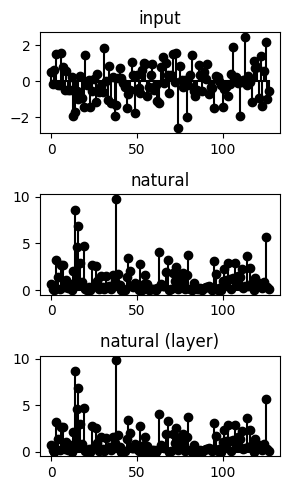

In [9]:


L = h2.shape[0] #filter length
# n = tf.range(L) 
Npoint = x.shape[0]
# Npoint = len(x)
paddings = [
        [0, Npoint - L],  # Depth dimension
        [0, Npoint - L]
        #    0,
        #    0,
        ]
# x
Npoint, paddings
h_padded = tf.pad(h2, paddings, mode='CONSTANT', constant_values=0)
print('h_padded', h_padded)
h_padded.shape



x2 = tf.einsum('i,j->ij',x,x)
x2

### NAtural domain (alternative)
# q2 = tf.einsum('ijk,jk->i', h_columns_shifted, x2) ## faster
# slower version 
import numpy as np
def compute_q2(x2, h2):
    N = x2.shape[0]
    q2 = np.zeros(N).astype(float)
    for n in range(N):
        q2[n] = np.sum(h2 * x2[np.mod(n-np.arange(N), N),:][:, np.mod(n-np.arange(N), N)])
        print(x2[np.mod(n-np.arange(N), N),:][:, np.mod(n-np.arange(N), N)].shape)
    return q2

q2 = compute_q2(x2.numpy(),h_padded.numpy())
q2

plt.figure(figsize=(3,5))
plt.subplot(3,1,1), plt.stem(tf.squeeze(x).numpy(),'k', basefmt="k"), plt.title(f'input')
plt.subplot(3,1,2), plt.stem(tf.squeeze(q2).numpy(),'k', basefmt="k"), plt.title(f'natural')
# plt.subplot(3,1,3), plt.stem(tf.squeeze(y2).numpy(),'k', basefmt="k"), plt.title(f'Volterra (haar)')
plt.subplot(3,1,3), plt.stem(tf.squeeze(ylay).numpy(),'k', basefmt="k"), plt.title(f'natural (layer)')

plt.tight_layout()

In [ ]:

# h = tf.constant([1,2], dtype=tf.float32)

# # %% Quadratic kernel (m=2)
# #"""Quadratic kernel"""
# # x = [0,0,0,1,0,0,0,0]
# # filter init
# # h = tf.constant([1, 2, 1])
# h2 = tf.einsum('i,j->ij', h, h)
# print(h2)
# L = h.shape[0] #filter length
# # n = tf.range(L) 
# Npoint = x.shape[0]
# # Npoint = len(x)
# paddings = [
#         [0, Npoint - L],  # Depth dimension
#         [0, Npoint - L]
#         #    0,
#         #    0,
#         ]
# # x
# Npoint, paddings
# h_padded = tf.pad(h2, paddings, mode='CONSTANT', constant_values=0)
# print('h_padded', h_padded)
# h_padded.shape

# ## creating h[n-k1,n-k2]
# N = Npoint
# n = tf.range(N)
# # Create circular indices for all possible shifts
# # row_indices = tf.math.mod(n[:, tf.newaxis] - tf.range(N), L)  # [N, N]
# row_indices = tf.math.mod(n[:, tf.newaxis] - n, N)
# rows_shifted = tf.gather(h_padded, row_indices, axis=0)         # [N, N, N]
# rows_shifted
# h_columns_shifted = tf.gather(rows_shifted, row_indices,   # [N, N, N]
#                                 axis=2, batch_dims=1)
# h_columns_shifted, h_columns_shifted.shape




# _ = tf.expand_dims(tf.cast(h_columns_shifted, dtype=tf.float32), axis=-1)
# h_init = DWT2D(wave, clean=False)(_)
# print(tf.squeeze(h_init))

# H = tf.expand_dims(
#     tf.transpose(
#         DWT1D(wave, clean=False)(tf.transpose(tf.squeeze(h_init, axis=-1), perm=[1,0,2])),
#         perm=[1,0,2]),axis=-1)
# H[:,:,:,0]

# x2 = tf.einsum('i,j->ij',x,x)
# x2

# α2 = DWT2D(wave, clean=False)(tf.expand_dims(tf.expand_dims(x2, axis=-1),axis=0))
# α2.shape, tf.squeeze(α2)


# beta = tf.expand_dims(
#     tf.expand_dims(
#         tf.stack(
#             [tf.reduce_sum(H[k:k+1,:,:,:] * α2) for k in range(H.shape[0])]
#             ), axis=-1),axis=0)
# beta

# y2 = IDWT1D(wave, clean=False)(beta)
# y2



In [ ]:
# h = tf.constant([1,2], dtype=tf.float32)

# # %% Quadratic kernel (m=2)
# #"""Quadratic kernel"""
# # x = [0,0,0,1,0,0,0,0]
# # filter init
# # h = tf.constant([1, 2, 1])
# h2 = tf.einsum('i,j->ij', h, h)
# print(h2)